In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Load best model
best_model = joblib.load("../models/model_xgb_multi.pkl")

print("Libraries loaded!")
print(f"Best model loaded: {type(best_model).__name__}")

Libraries loaded!
Best model loaded: XGBClassifier


In [6]:
# Load exact feature names model was trained on
model_features = joblib.load("../models/feature_names.pkl")

# Reload dataset
df = pd.read_csv("../data/processed/diabetic_engineered.csv")

X = df[model_features]
y = df['readmitted_30']

# Same 70/15/15 split as Week 5
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Data loaded with correct 44 features!")
print(f"Test set shape: {X_test.shape}")

Data loaded with correct 44 features!
Test set shape: (15265, 44)


In [7]:
# Run SHAP explainer
print("Running SHAP explainer")

# Use a sample of 1000 rows for speed
X_sample = X_test.sample(1000, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed!")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value: {explainer.expected_value:.4f}")

Running SHAP explainer
SHAP values computed!
SHAP values shape: (1000, 44)
Expected value: 0.0174


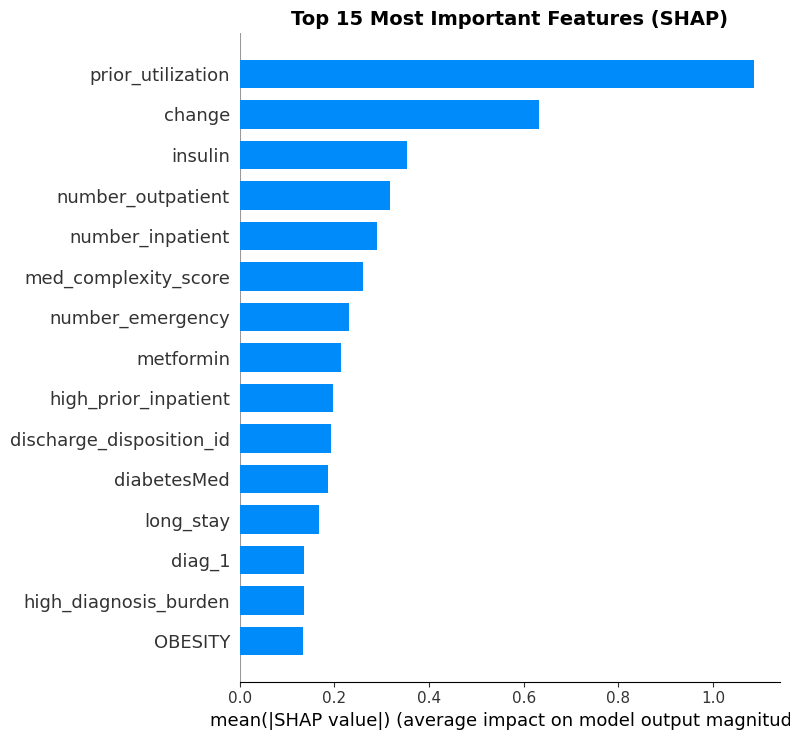

SHAP summary bar plot saved!


In [8]:
# SHAP Summary Plot(shows most important features)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Top 15 Most Important Features (SHAP)",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../explainability/shap_summary_bar.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary bar plot saved!")

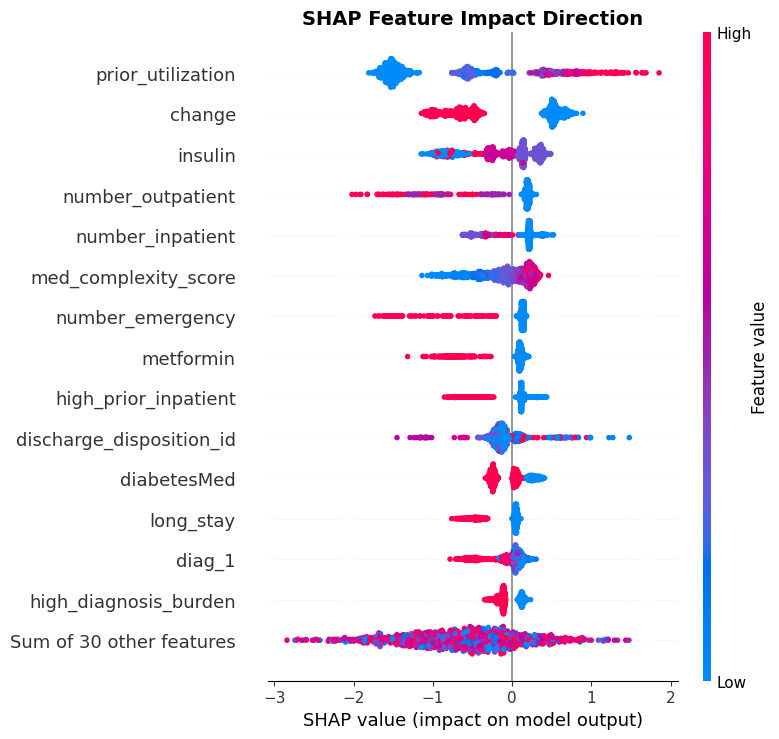

SHAP beeswarm plot saved!


In [9]:
# SHAP Beeswarm Plot(shows direction of impact)
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values,
        base_values=explainer.expected_value,
        data=X_sample.values,
        feature_names=model_features
    ),
    max_display=15,
    show=False
)
plt.title("SHAP Feature Impact Direction",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../explainability/shap_beeswarm.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP beeswarm plot saved!")

High risk patient risk score: 0.6925


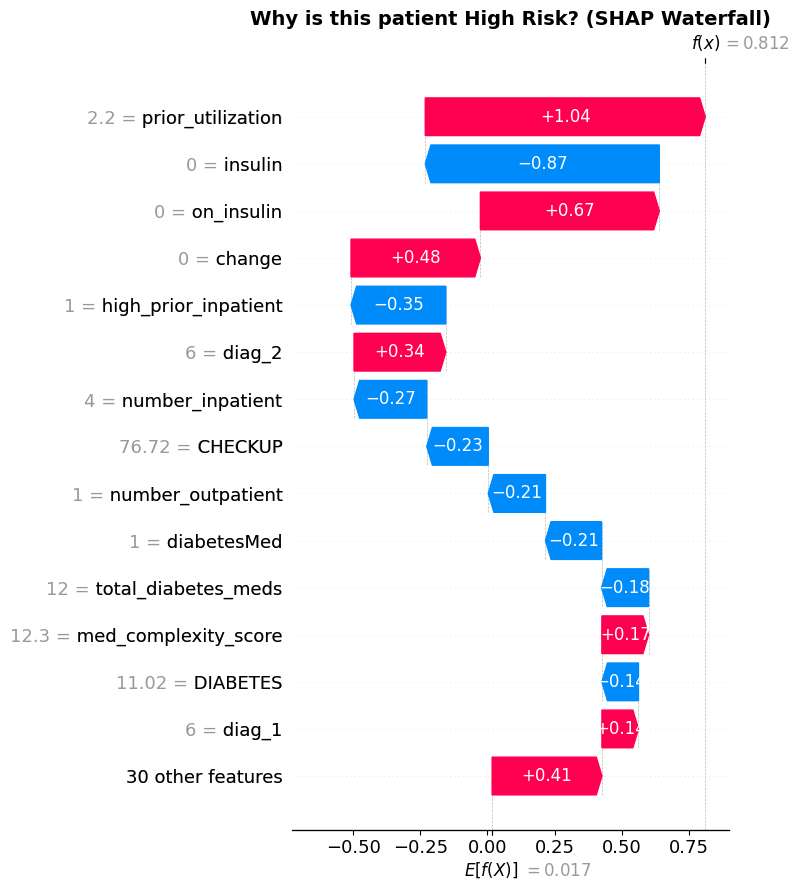

SHAP waterfall plot saved!


In [10]:
# SHAP Waterfall plot for one high risk patient
y_prob_sample = best_model.predict_proba(X_sample)[:, 1]
high_risk_idx = y_prob_sample.argmax()

print(f"High risk patient risk score: {y_prob_sample[high_risk_idx]:.4f}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[high_risk_idx],
        feature_names=model_features
    ),
    max_display=15,
    show=False
)
plt.title("Why is this patient High Risk? (SHAP Waterfall)",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../explainability/shap_waterfall.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP waterfall plot saved!")

In [11]:
# Export SHAP feature importance as CSV
shap_importance = pd.DataFrame({
    'feature': model_features,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

shap_importance.to_csv("../dashboard/shap_importance.csv", index=False)

print("SHAP importance saved!")
print(f"Top 15 most important features:")
print(shap_importance.head(15).to_string(index=False))

SHAP importance saved!
Top 15 most important features:
                 feature  importance
       prior_utilization    1.087121
                  change    0.632663
                 insulin    0.354031
       number_outpatient    0.316716
        number_inpatient    0.289026
    med_complexity_score    0.260045
        number_emergency    0.230864
               metformin    0.214195
    high_prior_inpatient    0.197351
discharge_disposition_id    0.192374
             diabetesMed    0.185635
               long_stay    0.166818
                  diag_1    0.135962
   high_diagnosis_burden    0.134892
                 OBESITY    0.133647


In [12]:
# Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

print("Running GridSearchCV")

# Apply SMOTE to training set
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Parameter grid
param_grid = {
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators':  [100, 200]
}

xgb_tune = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

grid_search = GridSearchCV(
    xgb_tune, param_grid,
    cv=3, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

# Use 20000 sample for speed
X_tune = pd.DataFrame(
    X_train_sm, columns=model_features).sample(20000, random_state=42)
y_tune = y_train_sm[X_tune.index]

grid_search.fit(X_tune, y_tune)

print(f"GridSearchCV done!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC: {grid_search.best_score_:.4f}")

Running GridSearchCV
Fitting 3 folds for each of 12 candidates, totalling 36 fits
GridSearchCV done!
Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
Best ROC-AUC: 0.9479


In [13]:
# Train final tuned model on full training set
print("Training tuned model with best parameters")

tuned_model = XGBClassifier(
    max_depth=8,
    learning_rate=0.1,
    n_estimators=200,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

tuned_model.fit(X_train_sm, y_train_sm)

# Evaluate on validation set
y_val_prob_tuned = tuned_model.predict_proba(X_val)[:, 1]
y_val_pred_tuned = (y_val_prob_tuned >= 0.5).astype(int)

from sklearn.metrics import recall_score, precision_score, f1_score

auc_tuned  = roc_auc_score(y_val, y_val_prob_tuned)
rec_tuned  = recall_score(y_val, y_val_pred_tuned)
prec_tuned = precision_score(y_val, y_val_pred_tuned)
f1_tuned   = f1_score(y_val, y_val_pred_tuned)

print("Tuned model trained!")
print(f"Validation Results:")
print(f"  ROC-AUC: {auc_tuned:.4f}")
print(f"  Recall: {rec_tuned:.4f}")
print(f"  Precision: {prec_tuned:.4f}")
print(f"  F1-Score: {f1_tuned:.4f}")

# Compare with original model
print(f"Improvement over original XGBoost multi-source:")
print(f"  ROC-AUC: 0.6332 - {auc_tuned:.4f} (+{auc_tuned-0.6332:.4f})")

Training tuned model with best parameters
Tuned model trained!
Validation Results:
  ROC-AUC: 0.6362
  Recall: 0.0364
  Precision: 0.3351
  F1-Score: 0.0656
Improvement over original XGBoost multi-source:
  ROC-AUC: 0.6332 - 0.6362 (+0.0030)


In [26]:
# Save tuned model
joblib.dump(tuned_model, '../models/best_model_tuned.pkl')
print("Tuned model saved!")
print(f"  models/best_model_tuned.pkl")

# Save comparison
comparison = pd.DataFrame({
    'Model': ['XGBoost Original', 'XGBoost Tuned'],
    'ROC-AUC': [0.6332, auc_tuned],
    'Recall': [0.0423, rec_tuned],
    'Precision': [0.3172, prec_tuned],
    'F1-Score': [0.0746, f1_tuned]
}).round(4)

print(f"\nModel improvement comparison:")
print(comparison.to_string(index=False))

comparison.to_csv('../dashboard/tuning_comparison.csv', index=False)
print("Comparison saved!")

Tuned model saved!
  models/best_model_tuned.pkl

Model improvement comparison:
           Model  ROC-AUC  Recall  Precision  F1-Score
XGBoost Original   0.6332  0.0423     0.3172    0.0746
   XGBoost Tuned   0.6362  0.0364     0.3351    0.0656
Comparison saved!
